# Cuaderno de prueba para descarga de imágenes de GEE

In [1]:
!pip install earthengine-api requests rasterio matplotlib

In [2]:
import ee

PROJECT_ID = "golden-tide-482516-f7"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate(auth_mode="notebook")
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente")

Earth Engine inicializado correctamente


## Imports

In [3]:
import requests
import rasterio
import numpy as np
import matplotlib.pyplot as plt

## Definir un AOI más grande

In [4]:
lon, lat = -5.5012, 43.0270

point = ee.Geometry.Point([lon, lat])
aoi = point.buffer(1000).bounds()

print("Área aproximada del AOI (m²):", round(aoi.area(1).getInfo(), 2))

Área aproximada del AOI (m²): 3977969.28


## Función para enmascarar nubes y sombras

In [5]:
def mask_s2_sr(image):
    scl = image.select("SCL")
    
    mask = (
        scl.neq(0)   # No data
        .And(scl.neq(1))   # Saturated / defective
        .And(scl.neq(3))   # Cloud shadow
        .And(scl.neq(8))   # Cloud medium probability
        .And(scl.neq(9))   # Cloud high probability
        .And(scl.neq(10))  # Thin cirrus
        .And(scl.neq(11))  # Snow / ice
    )
    
    return image.updateMask(mask).copyProperties(image, image.propertyNames())

## Cargar colección y revisar cuántas escenas hay

In [6]:
raw_collection = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2024-06-01", "2024-09-30")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 40))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
)

num_images = raw_collection.size().getInfo()
print("Número de escenas candidatas:", num_images)

if num_images == 0:
    raise ValueError("No se encontraron imágenes. Prueba ampliando fechas o subiendo el límite de nubes.")

Número de escenas candidatas: 27


## Crear una composición limpia

In [7]:
clean_collection = raw_collection.map(mask_s2_sr)

rgb_image = (
    clean_collection
    .median()
    .select(["B4", "B3", "B2"])   # RGB
    .round()
    .toUint16()
    .clip(aoi)
)

print("Bandas:", rgb_image.bandNames().getInfo())

Bandas: ['B4', 'B3', 'B2']


## Generar URL de descarga

In [8]:
url = rgb_image.getDownloadURL({
    "region": aoi,
    "scale": 10,
    "format": "GEO_TIFF",
    "filePerBand": False,
    "name": "gee_prueba_rgb_aoi_grande"
})

print(url)

https://earthengine.googleapis.com/v1/projects/golden-tide-482516-f7/thumbnails/0691b6de30bf2359b02393cbe5b0b927-dda4e39197c1e9edf4e89fc15d4c5ee4:getPixels


## Descargar GeoTiff

In [9]:
out_path = "gee_prueba_rgb_aoi_grande.tif"

r = requests.get(url, stream=True, timeout=120)
r.raise_for_status()

with open(out_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print(f"Archivo guardado en: {out_path}")

Archivo guardado en: gee_prueba_rgb_aoi_grande.tif


## Metadatos

In [10]:
with rasterio.open(out_path) as src:
    print("Bandas:", src.count)
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Tipo:", src.dtypes)

Bandas: 3
Tamaño: 273 x 201
CRS: EPSG:4326
NoData: 0.0
Bounds: BoundingBox(left=-5.513410056283563, bottom=43.01798333674517, right=-5.4888860490271005, top=43.036039473955974)
Tipo: ('uint16', 'uint16', 'uint16')


## Visualización QGIS

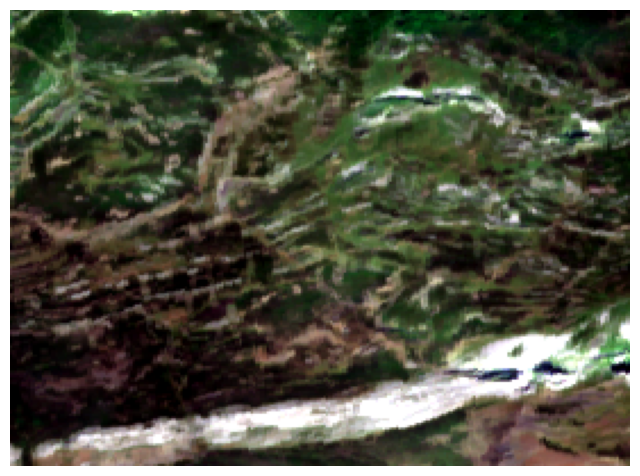

In [11]:
with rasterio.open(out_path) as src:
    data = src.read().astype(np.float32)

rgb = np.transpose(data, (1, 2, 0))  # (h, w, 3)

# Consideramos válidos los píxeles donde alguna banda sea distinta de 0
valid = np.any(rgb != 0, axis=2)

rgb_scaled = rgb.copy()

for i in range(3):
    band = rgb[..., i]
    vals = band[valid]
    
    if len(vals) > 0:
        p2, p98 = np.percentile(vals, (2, 98))
        if p98 > p2:
            rgb_scaled[..., i] = np.clip((band - p2) / (p98 - p2), 0, 1)
        else:
            rgb_scaled[..., i] = 0

rgb_scaled[~valid] = np.nan

plt.figure(figsize=(8, 8))
plt.imshow(rgb_scaled)
plt.axis("off")
plt.show()